# SPHERE IRD Extraction

In this tutorial, we focus on the observable extraction
from SPHERE IRD observations.

A lot of the steps in this notebook are similar to what is done in the
[Getting started tutorial](../../getting-started/). However, the parameters
used in this notebook provide a better starting point for SPHERE data.

In [1]:
from pathlib import Path

import amical

In [2]:
# TODO: Download link to data or include in repo?
datadir = Path("../NRM_DATA/TestSPHEREData/")

file_t = datadir / "HD142527_IRD_SCIENCE_DBI_LEFT_CUBE.fits"
file_c = datadir / "HD142695_IRD_SCIENCE_DBI_LEFT_CUBE.fits"

## Cleaning the data

We first clean the data with the usual steps.

Output()

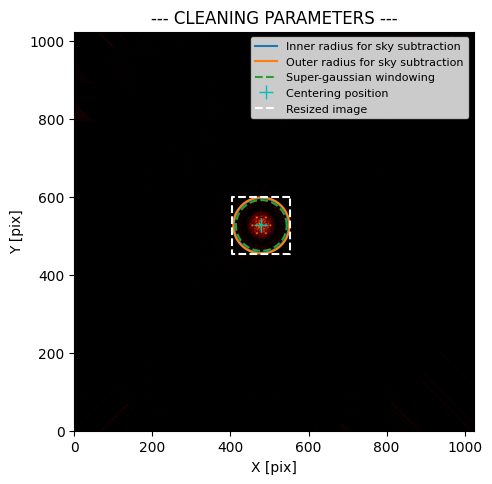

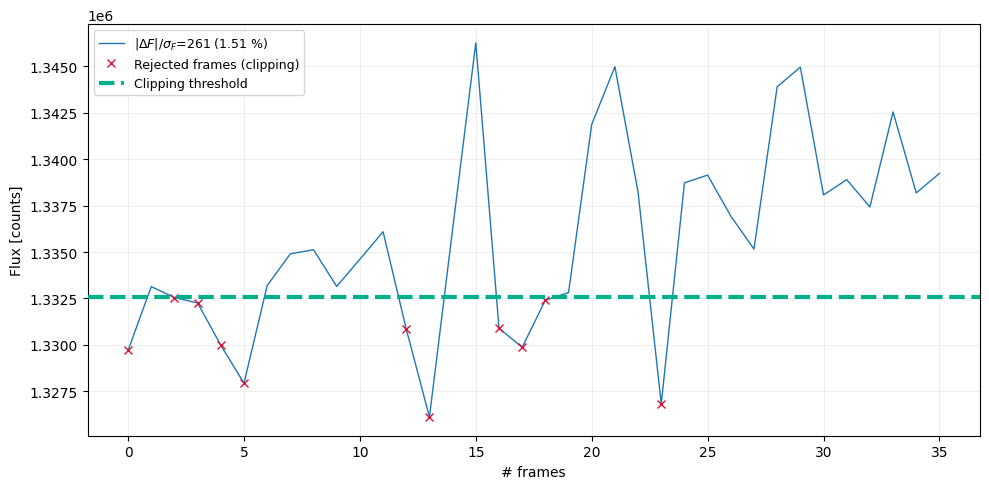

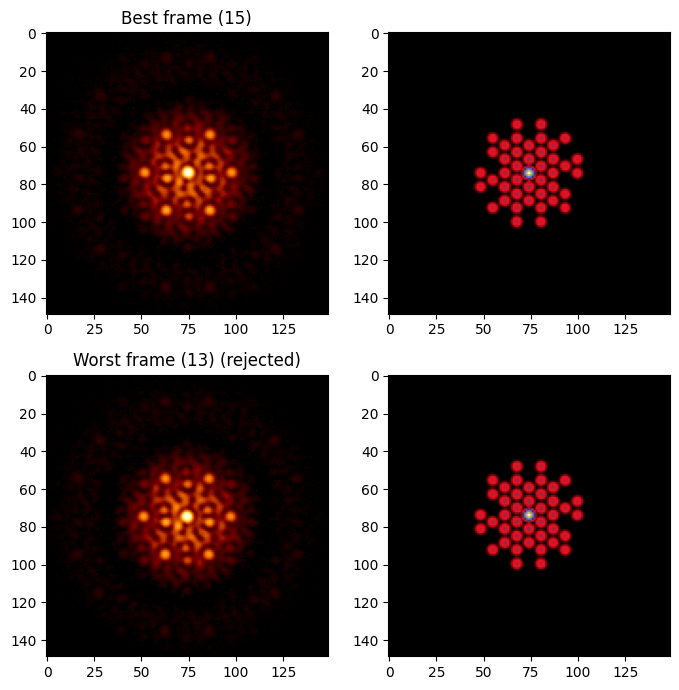

Output()

In [3]:
# ----------------------------------
# Cleaning step
# ----------------------------------

clean_param = {"isz": 149, "r1": 70, "dr": 2, "apod": True, "window": 65, "f_kernel": 3}

cube_t = amical.select_clean_data(file_t, clip=True, **clean_param, display=True)
cube_c = amical.select_clean_data(file_c, clip=True, **clean_param, display=False)

## Observable Extraction

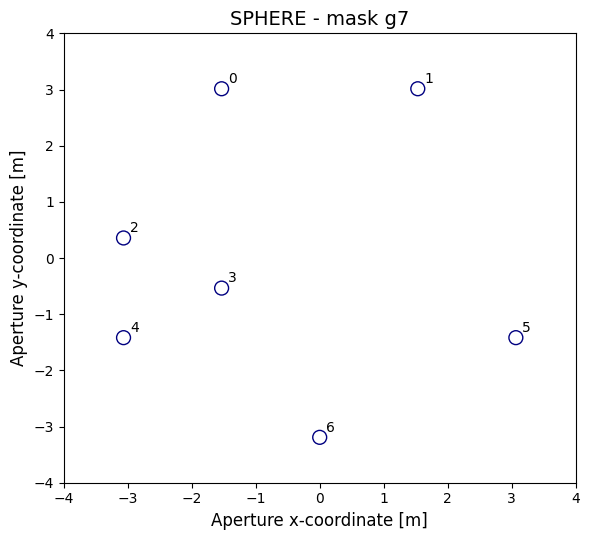

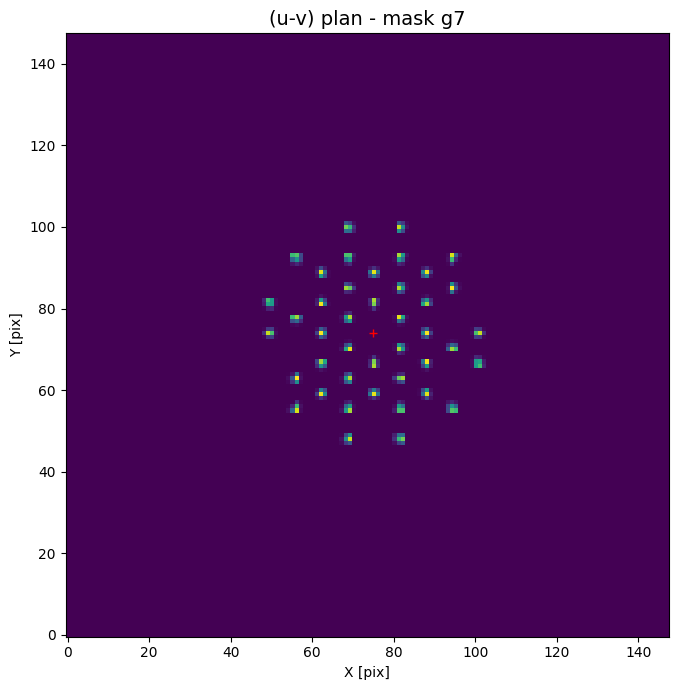

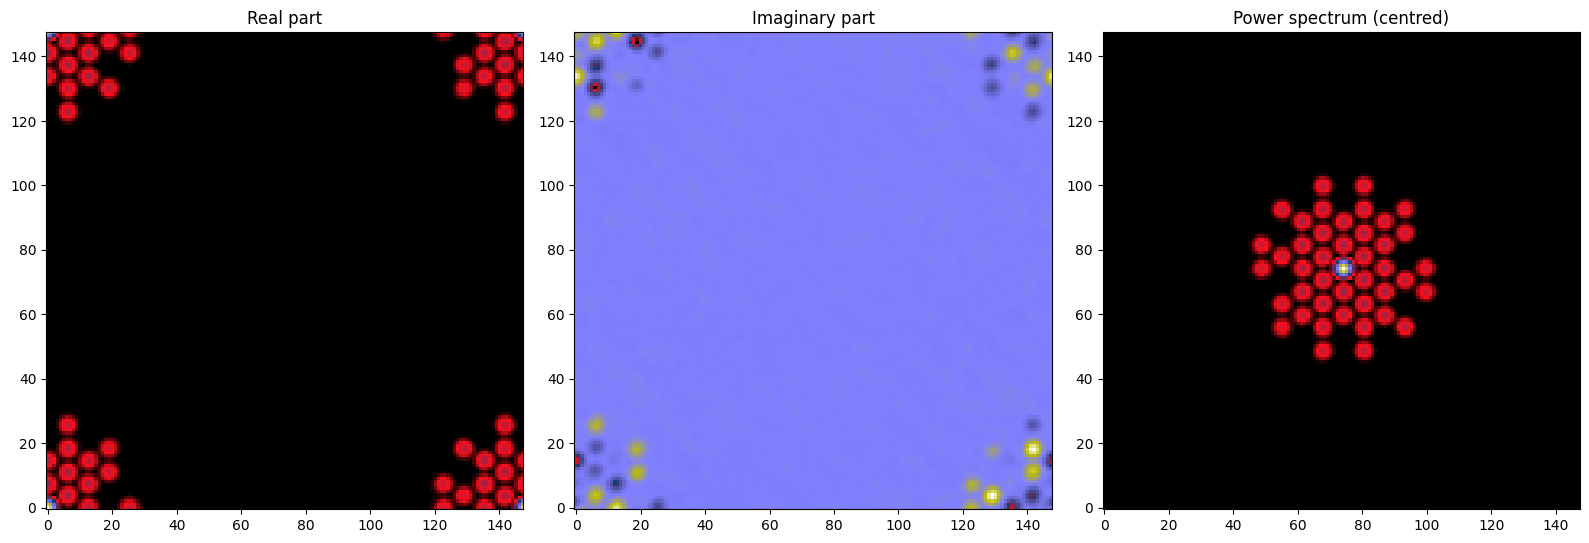

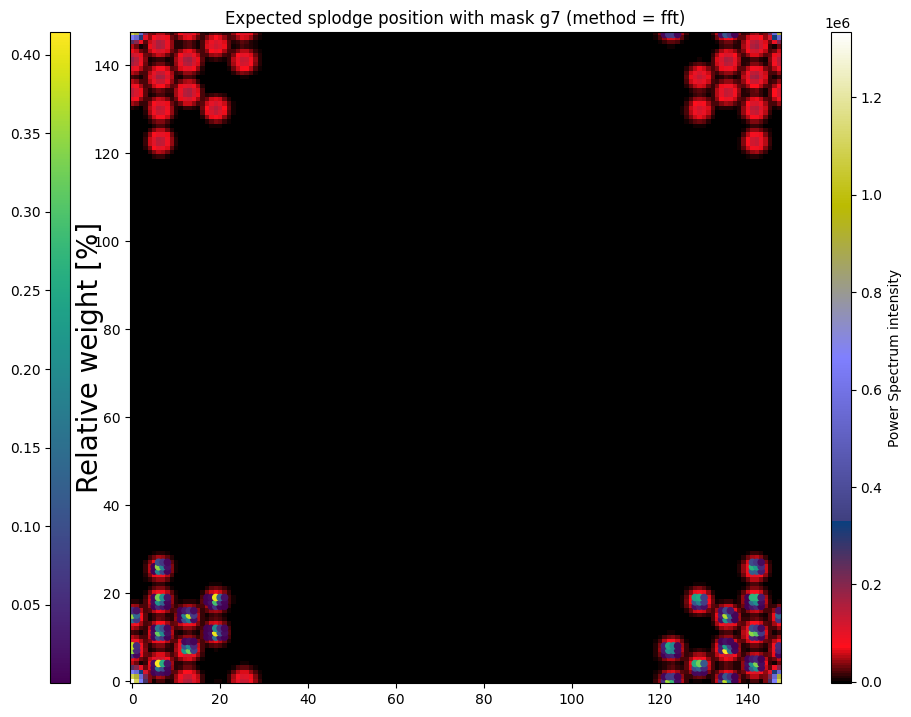

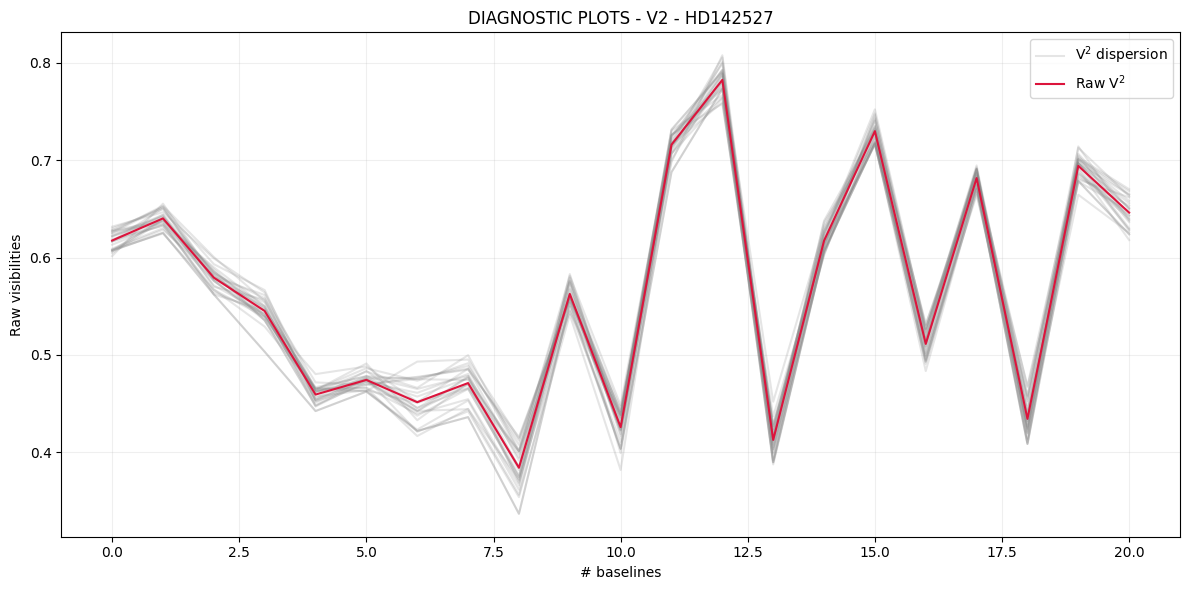

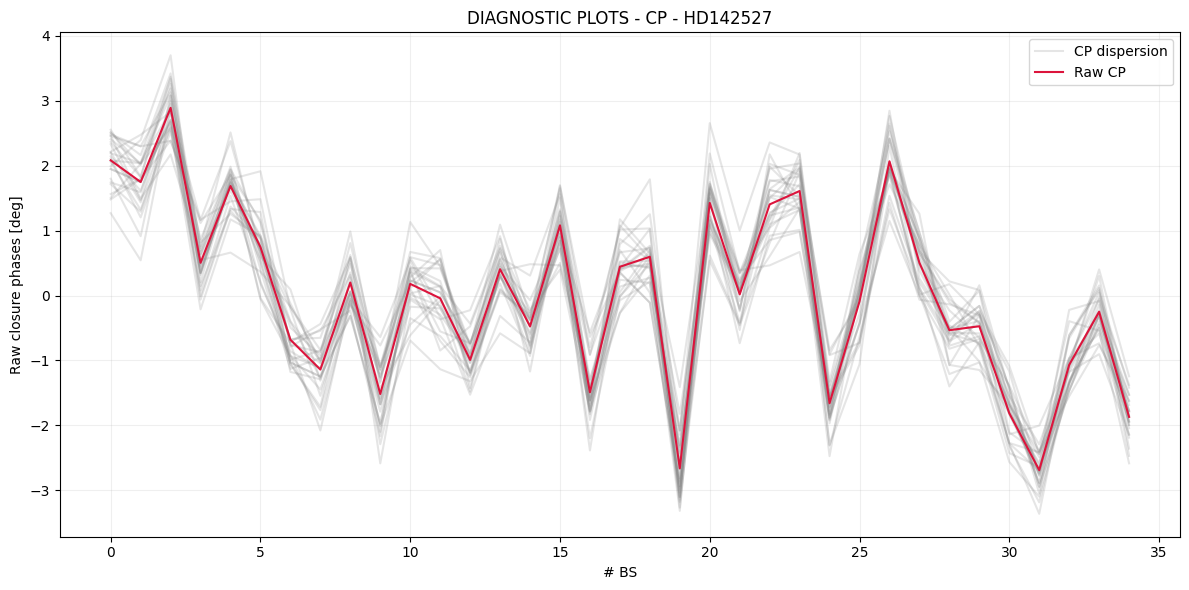

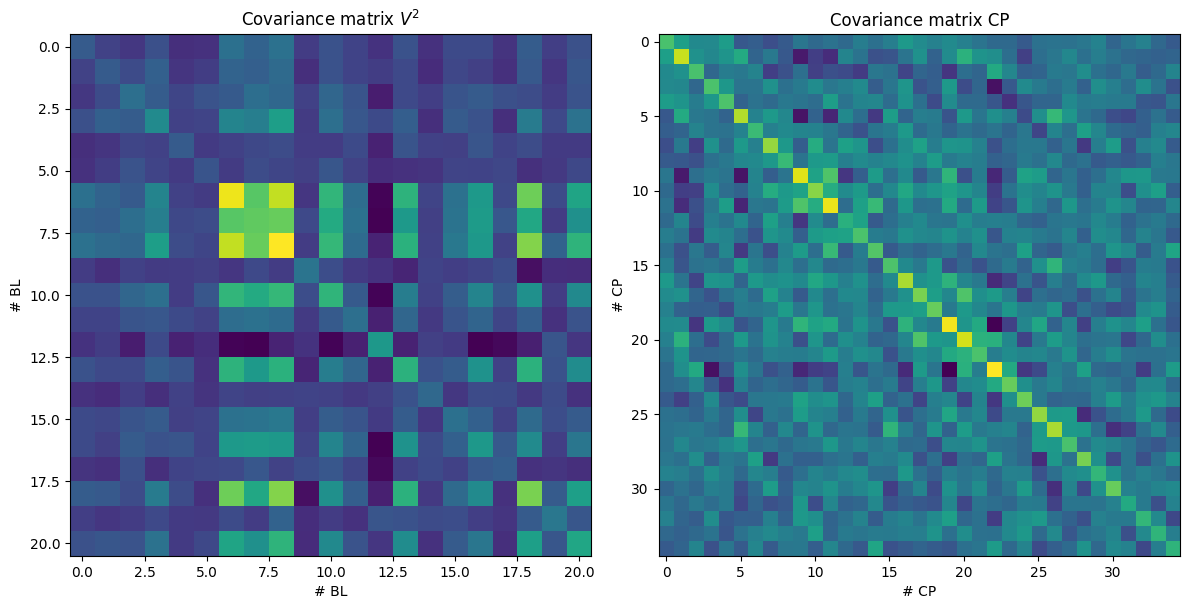

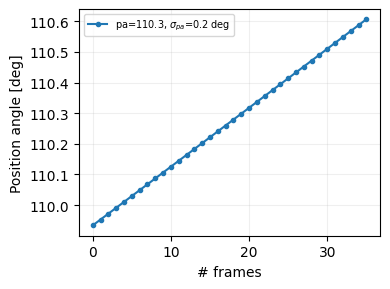

In [4]:
#  AMI parameters (refer to the docstrings of `extract_bs` for details)
params_ami = {
    "peakmethod": "fft",
    "bs_multi_tri": False,
    "maskname": "g7",
    "fw_splodge": 0.7,
    "filtname": "K1",
}

# # Extract raw complex observables for the target and the calibrator:
# # It's the core of the pipeline (amical/mf_pipeline/bispect.py)
bs_t = amical.extract_bs(
    cube_t, file_t, targetname="HD142527", **params_ami, display=True
)
bs_c = amical.extract_bs(
    cube_c, file_c, targetname="HD142695", **params_ami, display=False
)

## Checking the seeing

For ground-based observation, it may be interesting to visualize the seeing conditions.
This is especially useful if you have multiple FITS files and want to keep only the
ones with the best seeing.

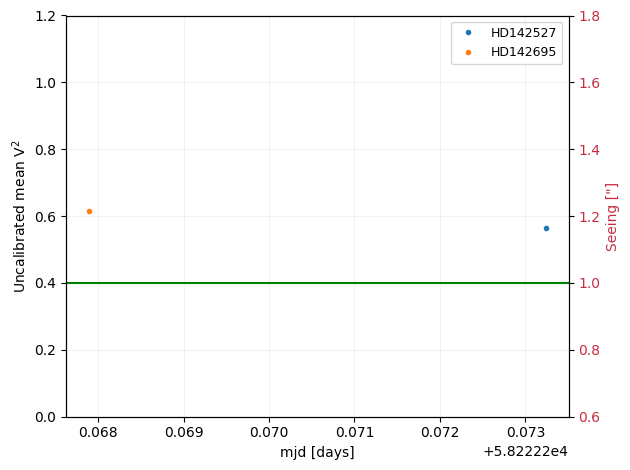

In [5]:
from amical.tools import check_seeing_cond, plot_seeing_cond

cond_t = check_seeing_cond([bs_t])
cond_c = check_seeing_cond([bs_c])
_ = plot_seeing_cond([cond_t, cond_c], lim_seeing=1)

## Calibration

Finally, the calibration step is exactly the same as with other instruments and modes.

In [6]:
cal = amical.calibrate(bs_t, bs_c)


 -- SHOW -- Inputs are classes from amical.calibrate:
-> (Check true_flag_v2, true_flag_t3 and snr parameters)



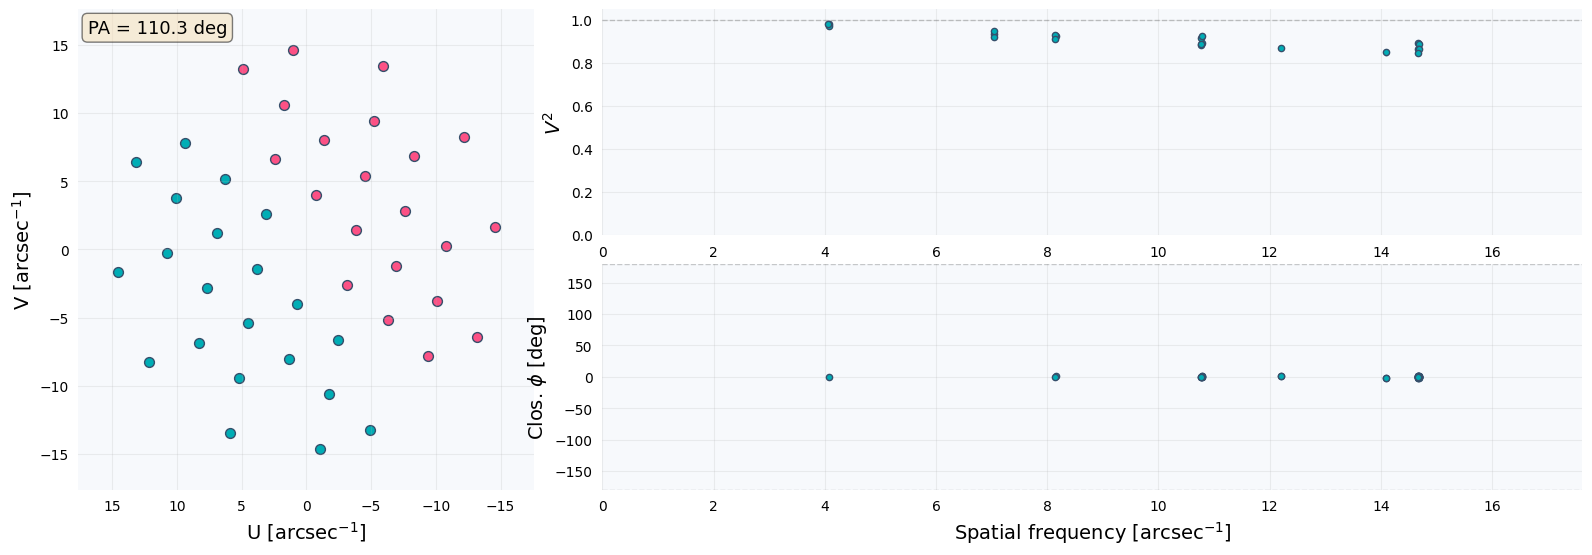

In [7]:
# Display and save the results as oifits
_ = amical.show(cal, true_flag_t3=False, cmax=180, pa=bs_t.infos.pa)